## How to implement FNO?

## Download dataset

Important notes:

- Make sure you download and save the dataset from (https://drive.google.com/file/d/1tsSyxcSSKkQ2SWsSpId8s5bKFgbn8boI/view?usp=sharing) to your google drive or your local computer
- Make sure you choose GPU in the Runtime/Change runtime type or use GPU in your local computer


In [ ]:
#load data
import os
from google.colab import drive
import warnings

warnings.filterwarnings('ignore')

def is_running_on_colab():
    return 'COLAB_GPU' in os.environ

# Use the function to check
if is_running_on_colab():
    print("This notebook is running on Google Colab.")

    # Mount your Google Drive.
    drive.mount("/content/drive")

    # check whether the dataset is already in your google drive or local computer
    # make sure burgers_data_R10.mat is in this folder of your google drive
    !ls /content/drive/MyDrive/Colab_Notebooks/Compumag2025.3.20

    # used for Colab. You need to change the path for your file
    dataset_path = '/content/drive/MyDrive/Colab_Notebooks/Compumag2025.3.20/data.mat'
else:
    print("This notebook is not running on Google Colab.")
    dataset_path = 'dataset/data.mat' # put the dataset in a relative path

This notebook is running on Google Colab.
Mounted at /content/drive
“Attemp1.ipynb”（副本）  data.mat


## Import python packages

In [ ]:
!pip install pytorch-lightning

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 825.4/825.4 kB 25.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 97.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 70.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 59.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 12.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 60.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 962.6/962.6 kB 53.3 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-

In [ ]:
import os

import matplotlib.pyplot as plt
import numpy as np
import pytorch_lightning as pl
from pytorch_lightning.callbacks import ModelCheckpoint
from pytorch_lightning import seed_everything
from scipy.io import loadmat
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

import h5py

In [ ]:
def setup_seed(seed):
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    # 保证每次运行结果一样
    # 在神经网络中，参数默认是进行随机初始化的。
    #如果不设置的话每次训练时的初始化都是随机的，导致结果不确定。
    #如果设置初始化，则每次初始化都是固定的。

# 设置随机数种子  设定固定的随机数以便结果可以复现
setup_seed(88888)

## System configuration

In [ ]:
os.environ['CUDA_VISIBLE_DEVICES'] = '0'  # 使用 GPU 0
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [ ]:
import torch
print(torch.cuda.is_available())
print(torch.cuda.device_count())
print(torch.cuda.get_device_name(0))

False
0


RuntimeError: Found no NVIDIA driver on your system. Please check that you have an NVIDIA GPU and installed a driver from http://www.nvidia.com/Download/index.aspx

### Define FNO model

In [ ]:
#实现了保留低频信号
class SpectralConv1d(nn.Module):
    """
    Spectral Convolutional 1D Layer.

    Args:
        in_channels (int): Number of input channels.
        out_channels (int): Number of output channels.
        modes1 (int): Number of Fourier modes to multiply, at most floor(N/2) + 1.

    Attributes:
        in_channels (int): Number of input channels.
        out_channels (int): Number of output channels.
        modes1 (int): Number of Fourier modes to multiply, at most floor(N/2) + 1.
        scale (float): Scaling factor for the weights.
        weights1 (nn.Parameter): Learnable weights for the convolution.

    Methods:
        compl_mul1d(input, weights): Performs complex multiplication between input and weights.
        forward(x): Forward pass of the SpectralConv1d layer.
    """

    def __init__(self, in_channels, out_channels, modes1):
        super(SpectralConv1d, self).__init__()    #调用nn.Module的构造函数，确保SpectralConv1d继承了nn.Module的所有功能和特性
        self.in_channels = in_channels
        self.out_channels = out_channels
        self.modes1 = modes1            #Number of Fourier modes are kept, at most floor(N/2) + 1

        self.scale = 1 / (in_channels * out_channels)
        self.weights1 = nn.Parameter(self.scale * torch.rand(in_channels, out_channels, self.modes1, dtype=torch.cfloat))

    def compl_mul1d(self, input, weights):  #通过 compl_mul1d 实现输入频域特征与权重的复数乘法。
        """
        Performs complex multiplication between input and weights.

        Args:
            input (torch.Tensor): Input tensor of shape (batch, in_channel, x).
            weights (torch.Tensor): Weights tensor of shape (in_channel, out_channel, x).

        Returns:
            torch.Tensor: Result of complex multiplication of input and weights, of shape (batch, out_channel, x).
        """
        # (batch, in_channel, x ), (in_channel, out_channel, x) -> (batch, out_channel, x)
        # in_channel is the common dimension along which the operation is performed.
        # It suggests that every channel (or feature) of the input is being transformed into a new set of channels (or features) in the output.
        # The operation iterates over each batch and each position x, multiplying the input channels
        # by the corresponding weights and summing the results to produce the output channels.

        # For a given position i in the x dimension and a given batch element:
        # Take all values in A at this position and batch (A[batch, :, i]) – a slice of shape (in_channel).
        # Take all corresponding values in B at this position (B[:, :, i]) – a matrix of shape (in_channel, out_channel).
        # Multiply these values element-wise and sum over the in_channel dimension.
        # This produces a vector of shape (out_channel), representing the transformed features at position i for this batch element.
        return torch.einsum("bix,iox->box", input, weights)   #torch.einsum（爱因斯坦求和）是一个高效的张量运算工具，可以指定多个张量的维度如何进行操作。

    def forward(self, x):
        # Compute Fourier coeffcients
        x_ft = torch.fft.rfft(x)  # [Batch, C_in, Nx] -> [Batch, C_in, Nx//2 + 1], eg. [20, 64, 128] -> [20, 64, 65]   利用 torch.fft.rfft 将输入信号从物理空间转换到频域空间。  [batch, channel, Spatial Dimension]  batch多少组数据进行梯度下降，channel:灰度图像,每个像素只有一个强度值，表示黑白灰度的强弱。通道数 = 1（单通道）。 彩色图像(RGB),每个像素有红、绿、蓝三个颜色值。通道数 = 3（RGB 三通道）。       Spatial Dimension:空间多少个像素
        #将像素点上的数值进行分解
        # Multiply relevant Fourier modes
        out_ft = torch.zeros(x.shape[0], self.out_channels, x.size(-1)//2 + 1,  device=x.device, dtype=torch.cfloat) # [Batch, Nc, Nx//2 + 1], eg. [20, 64, 65]
        # [Batch, C_in, self.modes1] * [C_in, C_out, self.modes1] -> [Batch, C_out, self.modes1]
        out_ft[:, :, :self.modes1] = self.compl_mul1d(x_ft[:, :, :self.modes1], self.weights1)   #保留低阶

        # Return to physical space
        x = torch.fft.irfft(out_ft, n=x.size(-1))  # [Batch, C_out, self.modes1] -> [Batch, C_out, Nx], eg. [20, 64, 65] -> [20, 64, 128]   利用 torch.fft.irfft 将频域结果转换回物理空间
        return x


#定义网络结构
class FNO1d(nn.Module):
    def __init__(self, modes, width):
        """
        1D Fourier Neural Operator model.

        Args:
            modes (int): Number of spectral modes.
            width (int): Number of hidden channel.
        """
        super(FNO1d, self).__init__()
        self.modes1 = modes #how many low frequency you want to keep
        self.width = width #hidden number of chanel
        self.fc0 = nn.Linear(43, self.width) # input channel is 2: (a(x), x) MeshgridTensor + initial condition    Initial condition and special cordinate  channel提升至64

        self.conv0 = SpectralConv1d(self.width, self.width, self.modes1)
        self.conv1 = SpectralConv1d(self.width, self.width, self.modes1)
        self.conv2 = SpectralConv1d(self.width, self.width, self.modes1)
        self.conv3 = SpectralConv1d(self.width, self.width, self.modes1)

        self.w0 = nn.Conv1d(self.width, self.width, 1)
        self.w1 = nn.Conv1d(self.width, self.width, 1)
        self.w2 = nn.Conv1d(self.width, self.width, 1)
        self.w3 = nn.Conv1d(self.width, self.width, 1)

        self.fc1 = nn.Linear(self.width, 128) #越多性能越好 NNlayer是在最后一个维度进行转换
        self.fc2 = nn.Linear(128, 1)

    def forward(self, x):
        # stage 1: lift the channel from 2 to self.width = 64
        x = self.fc0(x)         # [Batch, Nx, C] -> [Batch, Nx, Width], eg. [20, 128, 2] -> [20, 128, 64]   输入数据 v(x)
        x = x.permute(0, 2, 1)  # [Batch, C, Nx], eg. [20, 64, 128]

        # stage 2: integral operators u' = (W + K)(u).
        # W is the linear transformation; K is the spectral convolution kernel.
        x1 = self.conv0(x)      # [Batch, C, Nx], eg. [20, 64, 128]   64可以看作神经网络的输入，加权得到128个位置处的数值
        x2 = self.w0(x)         # [Batch, C, Nx], eg. [20, 64, 128]   线性变换
        x = x1 + x2          #线性相加
        x = F.relu(x)           # [Batch, C, Nx], eg. [20, 64, 128]   激活函数

        x1 = self.conv1(x)
        x2 = self.w1(x)
        x = x1 + x2
        x = F.relu(x)           # [Batch, C, Nx], eg. [20, 64, 128]

        x1 = self.conv2(x)
        x2 = self.w2(x)
        x = x1 + x2
        x = F.relu(x)           # [Batch, C, Nx], eg. [20, 64, 128]

        x1 = self.conv3(x)
        x2 = self.w3(x)
        x = x1 + x2             # [Batch, C, Nx], eg. [20, 64, 128]

        # stage 3: put the channel back to 1
        x = x.permute(0, 2, 1)  # [Batch, Nx, C], eg. [20, 128, 64]
        x = self.fc1(x)         # [Batch, Nx, C] -> [Batch, Nx, 128], eg. [20, 128, 64] -> [20, 128, 128]
        x = F.relu(x)
        x = self.fc2(x)         # [Batch, Nx, C] -> [Batch, Nx, 1], eg. [20, 128, 128] -> [20, 128, 1]

        # since there are only one output
        x = x.squeeze(-1)       # [Batch, Nx, 1] -> [Batch, Nx], eg. [20, 128, 1] -> [20, 128]

        return x


### Configuration

In [ ]:
class Config():
    #========================#
    # Training parameters
    #========================#
    # num_epoch = 500                  # number of training epoch
    num_epoch = 34                 # for debugging
    batch_size = 2000                  # batch size

    # Adam optimizer parameters
    weight_decay = 1e-4              # weight decay for Adam optimizer

    # learning rate decay parameters
    lr = 0.001                       # learning rate
    step_size = 100                  # step size for step-wise learning rate decay
    gamma = 0.5                      # the decay coefficient for step-wise learning rate decay

    modes = 32                       # number of Fourier modes to multiply, at most floor(N/2) + 1,Number of Fourier u want to keep
    width = 384                       # number of hidden channel

    #========================#
    # dataset information
    #========================#
    # download dataset from: https://drive.google.com/file/d/16a8od4vidbiNR3WtaBPCSZ0T3moxjhYe/view?usp=drive_link
    dataset_path = '/content/drive/MyDrive/Colab_Notebooks/Compumag2025.3.20/data.mat'
    sub = 1                             # downsample rate for spatial dimension
    resolution_original = 2**13         # original resolution of the dataset
    num_train = 9200                    # number of training data
    num_test = 800                      # number of test data

    #========================#
    # results
    #========================#
    model_path = 'results/model_burgers_R10'
    checkpoint_dir = 'results/checkpoints_burgers_R10'

cfg = Config()

### Dataset preparation

In [ ]:
def prepare_data(raw_data, sub, cfg):
    """
    Load raw data and prepare data loaders.
    """

    for i in range(2, 43): #  P1没有放进去
        globals()[f'P{i}_data'] = torch.Tensor(raw_data[f'P{i}'][:].T)

    print(f'[Dataset] downsampled raw data - P10_data: {P2_data.shape}')

    cX1_data=torch.Tensor(raw_data['cX1'][:].T)
    cY1_data=torch.Tensor(raw_data['cY1'][:].T)

    print(f'[Dataset] downsampled raw data - cX1_data: {cX1_data.shape}')


    #将所有数据放入一个列表中
    data_list = [globals()[f'P{i}_data'] for i in range(2, 43)]  # P1_data 到 P42_data
    data_list.append(cX1_data)  # 添加 cX1_data
    data_list.append(cY1_data)  # 添加 cY1_data


    #使用 torch.stack 沿着第 3 个维度堆叠
    x_data = torch.stack(data_list, dim=2)  # 假设原始数据形状为 (1000, 81)，堆叠后为 (1000, 81, 44)  81是因为有81个XY轴坐标点
    y_data = torch.Tensor(raw_data['R11'][:].T)
    print(f'[Dataset] downsampled raw data - x_data: {x_data.shape}, y_data: {y_data.shape}')





    x_train, y_train = x_data[:cfg.num_train, :], y_data[:cfg.num_train, :]
    x_test, y_test = x_data[-cfg.num_test:, :], y_data[-cfg.num_test:, :]

    print(f'[Dataset] downsampled raw data - x_train: {x_train.shape}, y_train: {y_train.shape}')
    print(f'[Dataset] downsampled raw data - x_test: {x_test.shape}, y_test: {y_test.shape}')


    # Create data loaders
    train_loader = DataLoader(TensorDataset(x_train, y_train), batch_size=cfg.batch_size, shuffle=True)
    test_loader = DataLoader(TensorDataset(x_test, y_test), batch_size=cfg.batch_size, shuffle=False)


    """
    x_data = torch.Tensor(raw_data['a'])[:, ::sub]  # (num_trajectory, Nx): (2048, 1024)
    y_data = torch.Tensor(raw_data['u'])[:, ::sub]  # (num_trajectory, Nx): (2048, 1024)
    print(f'[Dataset] downsampled raw data - x_data: {x_data.shape}, y_data: {y_data.shape}')

    # Split into train and test
    x_train, y_train = x_data[:cfg.num_train, :], y_data[:cfg.num_train, :]
    x_test, y_test = x_data[-cfg.num_test:, :], y_data[-cfg.num_test:, :]
    print(f'[Dataset] x_train: {x_train.shape}, y_train: {y_train.shape}')
    print(f'[Dataset] x_test: {x_test.shape}, y_test: {y_test.shape}')

    # Prepare grid information (optional)
    grid_all = np.linspace(0, 1, cfg.resolution_original).reshape(cfg.resolution_original, 1).astype(np.float64)
    grid = grid_all[::sub, :]
    grid = torch.tensor(grid, dtype=torch.float)

    # Concatenate the spatial grid and the spatial solution
    x_train = torch.cat([x_train.reshape(cfg.num_train, -1, 1), grid.repeat(cfg.num_train, 1, 1)], dim=2)
    x_test = torch.cat([x_test.reshape(cfg.num_test, -1, 1), grid.repeat(cfg.num_test, 1, 1)], dim=2)

    # Create data loaders
    train_loader = DataLoader(TensorDataset(x_train, y_train), batch_size=cfg.batch_size, shuffle=True)
    test_loader = DataLoader(TensorDataset(x_test, y_test), batch_size=cfg.batch_size, shuffle=False)



    # 提取第三个维度的第三个通道（索引为 2）
    third_channel_data = x_data[:, :, 1]  # 形状为 (36, 100)

    # 打印平面数据
    print("Plane data (shape: (36, 100)) - Third channel of the third dimension:")
    print(third_channel_data)


"""


    return train_loader, test_loader




class DataModule(pl.LightningDataModule):
    """
    Data module for loading data in PyTorch Lightning.
    """
    def __init__(self, dataset_path, sub, cfg):
        super(DataModule, self).__init__()
        self.dataset_path = dataset_path
        self.sub = sub
        self.cfg = cfg
        self.train_loader = None
        self.test_loader = None

    def setup(self, stage=None):
        # 读取 HDF5 格式的 .mat 数据
        with h5py.File(self.dataset_path, 'r') as raw_data:
            print("[DataModule] Loading HDF5 .mat dataset...")
            self.train_loader, self.test_loader = prepare_data(raw_data, self.sub, self.cfg)
        print('[DataModule] Data loaders have been set up.')

    def train_dataloader(self):
        return self.train_loader

    def val_dataloader(self):
        return self.test_loader

    def test_dataloader(self):
        return self.test_loader

data_module = DataModule(cfg.dataset_path, cfg.sub, cfg)
data_module.setup()



[DataModule] Loading HDF5 .mat dataset...
[Dataset] downsampled raw data - P10_data: torch.Size([10000, 81])
[Dataset] downsampled raw data - cX1_data: torch.Size([10000, 81])
[Dataset] downsampled raw data - x_data: torch.Size([10000, 81, 43]), y_data: torch.Size([10000, 81])
[Dataset] downsampled raw data - x_train: torch.Size([9200, 81, 43]), y_train: torch.Size([9200, 81])
[Dataset] downsampled raw data - x_test: torch.Size([800, 81, 43]), y_test: torch.Size([800, 81])
[DataModule] Data loaders have been set up.


## Model training & evaluation

In [ ]:
class PlModel(pl.LightningModule):
    """
    PyTorch Lightning module for training the FNO model.
    """
    def __init__(self, cfg):
        super(PlModel, self).__init__()
        self.model = FNO1d(cfg.modes, cfg.width)
        self.cfg = cfg
        self.metrics = {'train_loss': [], 'val_loss': [], 'test_loss': []}

    def forward(self, x):
        return self.model(x)

    def training_step(self, batch, batch_idx):
        x, y = batch
        y_hat = self.model(x)
        loss = F.mse_loss(y_hat.view(-1, 1), y.view(-1, 1))
        self.log('train_loss', loss, on_step=False, on_epoch=True, prog_bar=True, logger=True)
        self.metrics['train_loss'].append(loss.item())
        return loss

    def validation_step(self, batch, batch_idx):
        x, y = batch
        y_hat = self.model(x)
        loss = F.mse_loss(y_hat.view(-1, 1), y.view(-1, 1))
        self.log('val_loss', loss, on_step=False, on_epoch=True, prog_bar=True, logger=True)
        self.metrics['val_loss'].append(loss.item())
        return loss

    def test_step(self, batch, batch_idx):
        x, y = batch
        y_hat = self.model(x)
        loss = F.mse_loss(y_hat.view(-1, 1), y.view(-1, 1))
        self.log('test_loss', loss, on_step=False, on_epoch=True, prog_bar=True, logger=True)
        self.metrics['test_loss'].append(loss.item())
        return loss

    def configure_optimizers(self):
        optimizer = torch.optim.Adam(self.model.parameters(), lr=self.cfg.lr, weight_decay=self.cfg.weight_decay)
        scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=self.cfg.step_size, gamma=self.cfg.gamma)
        return [optimizer], [scheduler]

    def evaluate_at_different_resolutions(self, raw_data):
            self.eval()
            with torch.no_grad():
               pred = self(raw_data)
            return pred

In [ ]:
# train the model
model = PlModel(cfg)

checkpoint_callback = ModelCheckpoint(
    monitor='val_loss',
    dirpath=cfg.checkpoint_dir,
    filename='fno-{epoch:02d}-{val_loss:.2f}',
    save_top_k=1,
    mode='min',
)

trainer = pl.Trainer(
    max_epochs=cfg.num_epoch,
    callbacks=[checkpoint_callback],
    accelerator='gpu',
    devices=1,
    enable_progress_bar=True,
    # Note: I disabled progress bar to make the ouput cell
    # more clear for jupyter notebook. But it's better to enable it for python script.
)
# train the model
trainer.fit(model, data_module)
# test the model
trainer.test(model, data_module.test_dataloader())


"""
# Evaluate the model at different resolutions
raw_data = loadmat(cfg.dataset_path)  # Ensure this is loaded correctly
resolution_test_list = [64, 256, 1024]
model.evaluate_at_different_resolutions(raw_data, resolution_test_list)
"""

MisconfigurationException: No supported gpu backend found!

In [ ]:
from google.colab import files
uploaded = files.upload()

# Load training data (boundary points), residual and interface points from .mat file
# All points are generated in Matlab

"""
main_folder_path = Path('.')
if not os.path.exists(main_folder_path / 'Contour_Plots_NL'):
    os.makedirs(main_folder_path / 'Contour_Plots_NL')
"""

# 假设上传的文件名是 'data1.mat'
file_path = 'data1.mat'

# 加载 .mat 文件
with h5py.File(file_path, 'r') as file:
    data1 =  {key: torch.tensor(file[key][:].T, dtype=torch.float32) for key in file.keys()}  # Convert to PyTorch tensor and transpose



for i in range(2, 43): #  P1没有放进去
    globals()[f'P{i}_pre'] = data1[f'P{i}'][:]



cX1_pre=data1['cX1'][:]
cY1_pre=data1['cY1'][:]


#将所有数据放入一个列表中
data_list = [globals()[f'P{i}_pre'] for i in range(2, 43)]  # P1_data 到 P42_data
data_list.append(cX1_pre)  # 添加 cX1_data
data_list.append(cY1_pre)  # 添加 cY1_data


#使用 torch.stack 沿着第 3 个维度堆叠
raw_data = torch.stack(data_list, dim=2)  # 假设原始数据形状为 (1000, 81)，堆叠后为 (1000, 81, 44)  81是因为有81个XY轴坐标点



print(raw_data.shape)


pred=model.evaluate_at_different_resolutions(raw_data)





Saving data1.mat to data1 (10).mat
torch.Size([1, 81, 43])


In [ ]:
print(pred)

tensor([[ 0.7509,  0.7669,  0.6945,  0.6970,  0.6457,  0.5769,  0.5538,  0.4769,
          0.4374,  0.7534,  0.7519,  0.7022,  0.6864,  0.6265,  0.5516,  0.5146,
          0.4296,  0.3496,  0.7140,  0.6953,  0.6436,  0.6255,  0.5659,  0.5001,
          0.4643,  0.3716,  0.2714,  0.6741,  0.6469,  0.5795,  0.5569,  0.4963,
          0.4342,  0.3911,  0.3032,  0.2164,  0.6482,  0.6083,  0.5222,  0.4917,
          0.4296,  0.3679,  0.3277,  0.2408,  0.1748,  0.6387,  0.5719,  0.4588,
          0.4171,  0.3657,  0.3046,  0.2541,  0.1815,  0.1271,  0.6072,  0.4862,
          0.3725,  0.3414,  0.2994,  0.2309,  0.1749,  0.1130,  0.0642,  0.5311,
          0.3918,  0.2685,  0.2468,  0.2186,  0.1345,  0.0676,  0.0215, -0.0272,
          0.3426,  0.1670,  0.0990,  0.1209,  0.1325,  0.0323, -0.0334, -0.0469,
         -0.0318]])


In [ ]:
#Download the value of R_pred
#Save xy
import numpy as np
from google.colab import files

# 将预测的结果从 GPU 移到 CPU
R_pred_cpu = pred.detach().cpu()

# 现在可以安全地将张量转换为 NumPy 数组
R_pred_numpy = R_pred_cpu.numpy()




np.savetxt('R_pred_numpy.csv', R_pred_numpy, delimiter=',')
files.download('R_pred_numpy.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### Plot training and validation loss

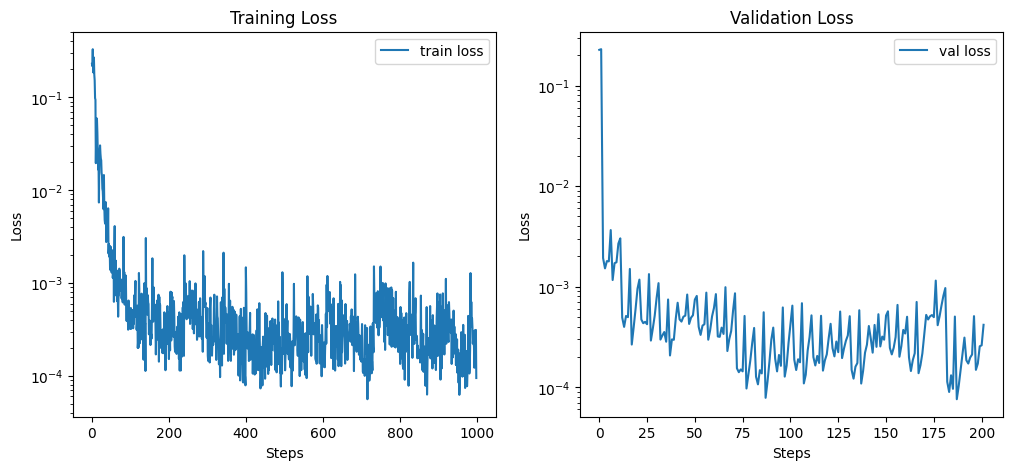

In [ ]:
# plot the training loss and validation loss in two subplots
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(model.metrics['train_loss'], label='train loss')
plt.xlabel('Steps')
plt.ylabel('Loss')
plt.yscale('log')
plt.title('Training Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(model.metrics['val_loss'], label='val loss')
plt.xlabel('Steps')
plt.ylabel('Loss')
plt.yscale('log')
plt.title('Validation Loss')
plt.legend()
plt.show()

## Homework

To get better performance, you can increase `num_epoch` to 500 and train the model again. You will see the loss can be much smaller.

You can also use other techniques, such as different batch sizes or learning rates or learning rate decay schemes to get better performance.

# Reference

- FNO paper: Li, Z., Kovachki, N., Azizzadenesheli, K., Liu, B., Bhattacharya, K., Stuart, A., & Anandkumar, A. (2020). Fourier neural operator for parametric partial differential equations. arXiv preprint arXiv:2010.08895
- FNO official github: https://github.com/neuraloperator/neuraloperator/?tab=readme-ov-file
- FNO tutorial: https://github.com/Ceyron/machine-learning-and-simulation/blob/main/english/neural_operators/simple_FNO_in_JAX.ipynb
- DeepONet & FNO: https://github.com/lu-group/deeponet-fno
- FNO documentation: https://neuraloperator.github.io/neuraloperator/dev/user_guide/neural_operators.html
- FNO blog: https://zongyi-li.github.io/blog/2020/fourier-pde/
- FNO news: https://www.technologyreview.com/2020/10/30/1011435/ai-fourier-neural-network-cracks-navier-stokes-and-partial-differential-equations/
- Wikipedia: https://en.wikipedia.org/wiki/Neural_operators
- Julia: https://docs.sciml.ai/NeuralOperators/stable/introduction/

## Citation
If you find this tutorial helpful, please cite it:
```
@book{xie2024sml,
  title={Hands-on Scientific Machine Learning},
  author={Xiaoyu Xie},
  url={https://xiaoyuxie.top/Sci-ML-Book},
  year={2024},
  publisher={WWW}
}
```